In [2]:
pip install numpy==1.26.4

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     -------------------------- ------------- 41.0/61.0 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 546.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/15.5 MB 4.3 MB/s eta 0:00:04
    --------------------------------------- 0.3/15.5 MB 2.9 MB/s eta 0:00:06
   - -------------------------------------- 0.4/15.5 MB 2.6 MB/s eta 0:00:06
   - -------------------------------------- 0.5/15.5 MB 2.6 MB/s eta 0:00:06
   - -------------------------------------- 0.8/15.5 MB 2.9 MB/s eta 0:00:06
   -- ------------------------------------- 0.9/15.5 MB 2.8 MB/s eta 0:00:06
   -- ------------------------------------- 1.0/15.5 MB 2.8 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/15.5 MB 2.7 MB/s eta 0:00:06
   --- ------------------------------------ 1.5/15.5 MB 2.6 MB/s eta 0:00:06
   --

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imagecodecs 2026.3.6 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Load data 
train_path = Path("train.csv")
if train_path.is_dir():
    candidate = train_path / "train.csv"
else:
    candidate = train_path
if not candidate.exists():
    alt = Path("train.csv") / "train.csv"
    if alt.exists():
        candidate = alt
    else:
        print("Current working directory:", Path.cwd())
        print("Directory listing:")
        for p in sorted(Path.cwd().iterdir()):
            print("  ", p.name, "(dir)" if p.is_dir() else "(file)")
        raise FileNotFoundError(f"Could not find 'train.csv' file; looked for {candidate}")
try:
    train = pd.read_csv(candidate, parse_dates=["date"])
except PermissionError as e:
    print("PermissionError when opening:", candidate)
    print("Candidate is_dir:", candidate.is_dir())
    print("Candidate exists:", candidate.exists())
    try:
        print(os.stat(candidate))
    except Exception as e2:
        print("stat error:", e2)
    raise

oil = pd.read_csv("oil.csv", parse_dates=["date"])

# Sort by time
train = train.sort_values("date")
oil = oil.sort_values("date")

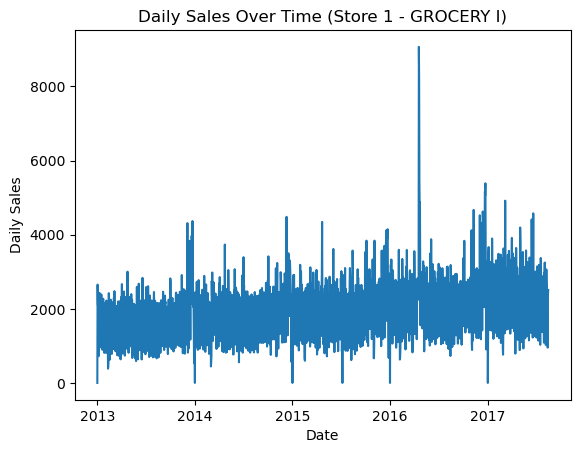

In [2]:
# Choose 1 store and 1 family
store_id = 1
family_name = "GROCERY I"

df_sample = train[
    (train["store_nbr"] == store_id) &
    (train["family"] == family_name)
]

plt.figure()
plt.plot(df_sample["date"], df_sample["sales"])
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title(f"Daily Sales Over Time (Store {store_id} - {family_name})")
plt.show()


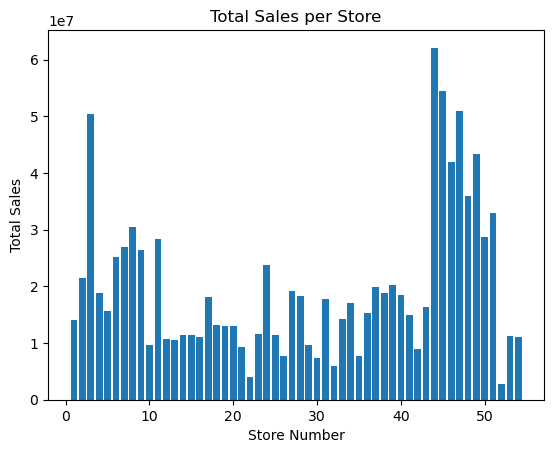

In [3]:
total_sales_per_store = train.groupby("store_nbr")["sales"].sum()

plt.figure()
plt.bar(total_sales_per_store.index, total_sales_per_store.values)
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.title("Total Sales per Store")
plt.show()


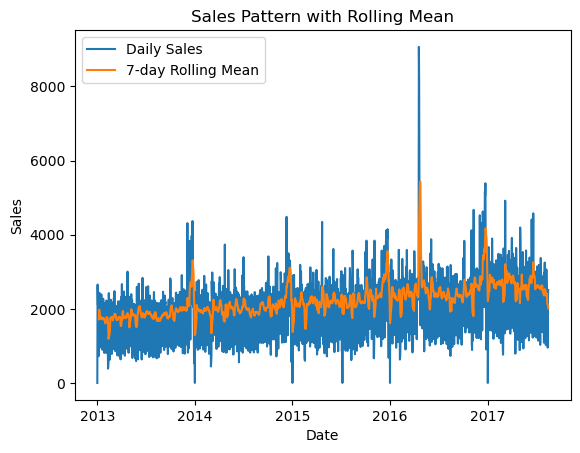

In [4]:
df_sample = df_sample.copy()
df_sample["rolling_7"] = df_sample["sales"].rolling(window=7).mean()

plt.figure()
plt.plot(df_sample["date"], df_sample["sales"], label="Daily Sales")
plt.plot(df_sample["date"], df_sample["rolling_7"], label="7-day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Pattern with Rolling Mean")
plt.legend()
plt.show()


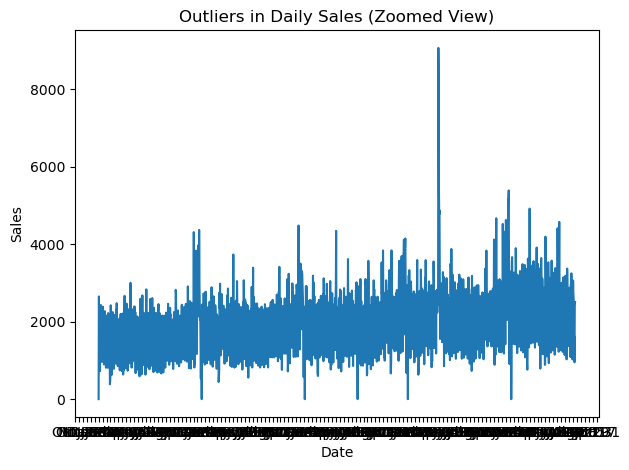

In [6]:
import matplotlib.dates as mdates

plt.figure()
plt.plot(df_sample["date"], df_sample["sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Outliers in Daily Sales (Zoomed View)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Load train data
train = pd.read_csv("./train.csv/train.csv")

print(train.head())
print(train.info())


   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
None


In [8]:
# Keep own id 
id_col = train["id"]

# Remove IDs for EDA & modeling
train = train.drop(columns=["id"])

# =========================
# STEP 2: Normalize data types
# =========================
train["date"] = pd.to_datetime(train["date"])
train["store_nbr"] = train["store_nbr"].astype("category")
train["family"] = train["family"].astype("category")


In [9]:
# =========================
# STEP 3: Sort by time and group keys
# =========================

train = train.sort_values(
    by=["store_nbr", "family", "date"]
).reset_index(drop=True)

In [10]:
# =========================
# STEP 4: Check for missing values
# =========================
print(train.isna().sum())


date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


In [11]:
# =========================
# STEP 5: Handle missing values
# =========================

train["onpromotion"] = train["onpromotion"].fillna(0)
missing_sales = train["sales"].isna().sum()
print("Missing sales:", missing_sales)


Missing sales: 0


In [12]:
# =========================
# STEP 6: Check for outliers
# =========================

# Negative sales are not reasonable
negative_sales = (train["sales"] < 0).sum()
print("Negative sales:", negative_sales)

# Days with sales = 0
zero_sales = (train["sales"] == 0).sum()
print("Zero sales:", zero_sales)


Negative sales: 0
Zero sales: 939130


In [13]:
# =========================
# STEP 7: Create EDA support column
# =========================

train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["dayofweek"] = train["date"].dt.dayofweek
train["is_weekend"] = train["dayofweek"].isin([5, 6]).astype(int)


In [14]:
# =========================
# STEP 8: Check the continuity of the time series
# =========================

# Example: check a random store & family
sample = train[
    (train["store_nbr"] == train["store_nbr"].cat.categories[0]) &
    (train["family"] == train["family"].cat.categories[0])
]
# Calculate the difference between the dates.
date_diff = sample["date"].diff().dt.days.value_counts()
print(date_diff.head())


date
1.0    1679
2.0       4
Name: count, dtype: int64


In [15]:
# =========================
# STEP 9: Save cleaned data
# =========================
train.to_csv("train_cleaned.csv", index=False)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    category      
 2   family       category      
 3   sales        float64       
 4   onpromotion  int64         
 5   year         int32         
 6   month        int32         
 7   dayofweek    int32         
 8   is_weekend   int32         
dtypes: category(2), datetime64[ns](1), float64(1), int32(4), int64(1)
memory usage: 120.2 MB
